In [1]:
import pandas as pd
import numpy as np

# ============================================================
# ANALYSE DER RAUCHBEDINGTEN STERBLICHKEIT IN DEUTSCHLAND
# Kombination beider Skripte in einem vollständigen Workflow
# ============================================================

print("=" * 90)
print("ANALYSE DER RAUCHBEDINGTEN STERBLICHKEIT IN DEUTSCHLAND")
print("Deutschland, 2024")
print("=" * 90)

# ============================================================
# 1. KONFIGURATION
# ============================================================

file_path = 'statistischer-bericht-todesursachen-2120400247005.xlsx'

# Smoking Attributable Fractions (WHO / CDC / Literatur)
SAF = {
    'C34': 0.88,      # Lungenkrebs
    'J44': 0.80,      # COPD
    'I20-I25': 0.25,  # Ischämische Herzkrankheiten
    'I60-I69': 0.18,  # Schlaganfall
    'C15': 0.70,      # Speiseröhrenkrebs
    'C25': 0.25,      # Bauchspeicheldrüsenkrebs
}

# ICD-Codes und Bezeichnungen
causes = {
    'C34': 'Lungenkrebs',
    'J44': 'COPD (chronische Bronchitis/Emphysem)',
    'I21': 'Akuter Myokardinfarkt',
    'I20-I25': 'Ischämische Herzkrankheiten',
    'I60-I69': 'Schlaganfall',
    'C15': 'Speiseröhrenkrebs',
    'C25': 'Bauchspeicheldrüsenkrebs',
}

# ============================================================
# 2. DATEN LADEN
# ============================================================

# Gesamt
df_total = pd.read_excel(file_path, sheet_name='23211-b09', header=0)

# Männer / Frauen
df_male = pd.read_excel(file_path, sheet_name='23211-b10', header=0)
df_female = pd.read_excel(file_path, sheet_name='23211-b11', header=0)

# Zeitreihe
df_time = pd.read_excel(file_path, sheet_name='23211-b01', header=0)

print("\nDaten erfolgreich geladen.")

# ============================================================
# 3. HILFSFUNKTIONEN
# ============================================================

def find_row_by_icd(df, code):
    """
    Sucht Zeile anhand eines ICD-Codes oder Präfixes.
    """
    for idx, row in df.iterrows():
        cell = str(row.iloc[0]).strip()

        if (
            cell.startswith(code)
            or cell.startswith(f"{code}:")
        ):
            return row

    return None


def get_deaths_by_icd(df, code):
    """
    Gibt die Todesfälle für einen ICD-Code zurück.
    """
    row = find_row_by_icd(df, code)

    if row is not None:
        return pd.to_numeric(row.iloc[1], errors='coerce')

    return 0


# ============================================================
# 4. GESAMTWERTE
# ============================================================

total_deaths = get_deaths_by_icd(df_total, 'A00-U85')
total_cancer = get_deaths_by_icd(df_total, 'C00-C97')

print(f"\nGesamtzahl aller Todesfälle: {total_deaths:,.0f}")
print(f"Gesamtzahl Krebstodesfälle:  {total_cancer:,.0f}")

# ============================================================
# 5. DETAILANALYSE DER TODESURSACHEN
# ============================================================

results = []

for code, name in causes.items():

    deaths_total = get_deaths_by_icd(df_total, code)
    deaths_male = get_deaths_by_icd(df_male, code)
    deaths_female = get_deaths_by_icd(df_female, code)

    saf = SAF.get(code, 0.0)

    attributable = deaths_total * saf

    results.append({
        'ICD': code,
        'Ursache': name,
        'Todesfälle_Gesamt': deaths_total,
        'Todesfälle_Männer': deaths_male,
        'Todesfälle_Frauen': deaths_female,
        'SAF': saf,
        'Zugeschriebene_Todesfälle': round(attributable),
        'Anteil_Gesamt_%': round((deaths_total / total_deaths) * 100, 2)
        if total_deaths else 0,
        'Anteil_Krebs_%': round((deaths_total / total_cancer) * 100, 2)
        if (
            total_cancer
            and 'krebs' in name.lower()
        ) else np.nan
    })

df_results = pd.DataFrame(results)

# Sortieren
df_results = df_results.sort_values(
    by='Todesfälle_Gesamt',
    ascending=False
)

# ============================================================
# 6. TABELLENAUSGABE
# ============================================================

print("\n" + "=" * 110)
print("DETAILLIERTE ANALYSE DER RAUCHBEDINGTEN TODESURSACHEN")
print("=" * 110)

print(
    f"{'Ursache':35} | "
    f"{'Gesamt':>12} | "
    f"{'Männer':>10} | "
    f"{'Frauen':>10} | "
    f"{'SAF':>6} | "
    f"{'Rauchen zurechenbar':>20}"
)

print("-" * 110)

for _, row in df_results.iterrows():

    print(
        f"{row['Ursache']:35} | "
        f"{row['Todesfälle_Gesamt']:>12,.0f} | "
        f"{row['Todesfälle_Männer']:>10,.0f} | "
        f"{row['Todesfälle_Frauen']:>10,.0f} | "
        f"{row['SAF']:>6.2f} | "
        f"{row['Zugeschriebene_Todesfälle']:>20,.0f}"
    )

print("-" * 110)

print(
    f"{'ALLE TODESFÄLLE':35} | "
    f"{total_deaths:>12,.0f}"
)

print(
    f"{'ALLE KREBSTODESFÄLLE':35} | "
    f"{total_cancer:>12,.0f}"
)

print("=" * 110)

# ============================================================
# 7. KURZANALYSE / WICHTIGSTE FAKTEN
# ============================================================

print("\n" + "=" * 90)
print("WICHTIGSTE FAKTEN AUF EINEN BLICK")
print("=" * 90)

# Einzelwerte
lung_cancer = get_deaths_by_icd(df_total, 'C34')
copd = get_deaths_by_icd(df_total, 'J44')
esophageal_cancer = get_deaths_by_icd(df_total, 'C15')
pancreatic_cancer = get_deaths_by_icd(df_total, 'C25')

ihd = get_deaths_by_icd(df_total, 'I20-I25')
stroke = get_deaths_by_icd(df_total, 'I60-I69')
ami = get_deaths_by_icd(df_total, 'I21')

# Direkte Folgen
direct_smoking = (
    lung_cancer
    + copd
    + esophageal_cancer
    + pancreatic_cancer
)

print("\n1️⃣ DIREKT MIT RAUCHEN VERBUNDENE ERKRANKUNGEN")
print(f"   • Lungenkrebs:                 {lung_cancer:>10,.0f}")
print(f"   • COPD:                        {copd:>10,.0f}")
print(f"   • Speiseröhrenkrebs:           {esophageal_cancer:>10,.0f}")
print(f"   • Bauchspeicheldrüsenkrebs:    {pancreatic_cancer:>10,.0f}")

print("   ─────────────────────────────────────────────")
print(
    f"   GESAMT:                       {direct_smoking:>10,.0f} "
    f"({direct_smoking / total_deaths * 100:.1f}% aller Todesfälle)"
)

# Herz-Kreislauf
print("\n2️⃣ HERZ-KREISLAUF-ERKRANKUNGEN")
print(f"   • Ischämische Herzkrankheiten: {ihd:>10,.0f}")
print(f"   • Akuter Myokardinfarkt:       {ami:>10,.0f}")
print(f"   • Schlaganfall:                {stroke:>10,.0f}")

print("   ─────────────────────────────────────────────")
print(
    f"   GESAMT:                       {ihd + stroke:>10,.0f} "
    f"({(ihd + stroke) / total_deaths * 100:.1f}% aller Todesfälle)"
)

# Gesamt
total_smoking_related = direct_smoking + ihd + stroke

print("\n3️⃣ GESAMTERGEBNIS")
print(
    f"   Mit Rauchen direkt oder indirekt verbundene Todesfälle:"
)

print(f"   {total_smoking_related:,.0f} Menschen")

print(
    f"   Das entspricht "
    f"{total_smoking_related / total_deaths * 100:.1f}% "
    f"aller Todesfälle in Deutschland."
)

# Kontext
print("\n4️⃣ KONTEXT")
print(
    f"   • Alle Krebstodesfälle:           {total_cancer:,.0f}"
)

print(
    f"   • Anteil Lungenkrebs an Krebs:    "
    f"{lung_cancer / total_cancer * 100:.1f}%"
)

print(
    f"   • Ischämische Herzkrankheiten > "
    f"alle Krebsarten zusammen: "
    f"{'JA' if ihd > total_cancer else 'NEIN'}"
)

print(
    f"   • Ischämische Herzkrankheiten > "
    f"Lungenkrebs + COPD: "
    f"{'JA' if ihd > lung_cancer + copd else 'NEIN'}"
)

# ============================================================
# 8. RAUCHEN ZURECHENBARE TODESFÄLLE (SAF)
# ============================================================

total_attributable = df_results[
    'Zugeschriebene_Todesfälle'
].sum()

print("\n" + "=" * 90)
print("RAUCHEN ZURECHENBARE TODESFÄLLE (SAF-MODELL)")
print("=" * 90)

print(
    f"\nGeschätzte Todesfälle direkt durch Rauchen "
    f"(epidemiologische Attribution):"
)

print(f"{total_attributable:,.0f} Todesfälle")

print(
    f"Das entspricht "
    f"{total_attributable / total_deaths * 100:.1f}% "
    f"aller Todesfälle."
)

# ============================================================
# 9. ZEITREIHEN
# ============================================================

print("\n" + "=" * 90)
print("ZEITREIHEN DER GESAMTSTERBLICHKEIT")
print("=" * 90)

try:
    print(df_time[['Jahr', 'Insgesamt']].tail(15))
except:
    print("Zeitreihenspalten konnten nicht automatisch erkannt werden.")

ANALYSE DER RAUCHBEDINGTEN STERBLICHKEIT IN DEUTSCHLAND
Deutschland, 2024

Daten erfolgreich geladen.

Gesamtzahl aller Todesfälle: 1,007,758
Gesamtzahl Krebstodesfälle:  230,392

DETAILLIERTE ANALYSE DER RAUCHBEDINGTEN TODESURSACHEN
Ursache                             |       Gesamt |     Männer |     Frauen |    SAF |  Rauchen zurechenbar
--------------------------------------------------------------------------------------------------------------
Ischämische Herzkrankheiten         |      113,473 |     65,435 |     48,038 |   0.25 |               28,368
Speiseröhrenkrebs                   |       69,884 |     39,480 |     30,404 |   0.70 |               48,919
Schlaganfall                        |       52,185 |     23,523 |     28,662 |   0.18 |                9,393
Lungenkrebs                         |       45,148 |     26,441 |     18,707 |   0.88 |               39,730
Akuter Myokardinfarkt               |       41,258 |     24,875 |     16,383 |   0.00 |                    0
C

                    Ursache     ICD  Todesfälle_Gesamt  Todesfälle_Männer  Todesfälle_Frauen  SAF  Zugeschriebene_Todesfälle  Anteil_Gesamt_%
                Lungenkrebs     C34              45148              26441              18707 0.88                      39730             4.48
                       COPD     J44              33650              17408              16242 0.80                      26920             3.34
Ischämische Herzkrankheiten I20-I25             113473              65435              48038 0.25                      28368            11.26
               Schlaganfall I60-I69              52185              23523              28662 0.18                       9393             5.18
          Speiseröhrenkrebs     C15              69884              39480              30404 0.70                      48919             6.93
   Bauchspeicheldrüsenkrebs     C25              19533               9844               9689 0.25                       4883             1.94


C:\Users\devdo\AppData\Local\Temp\ipykernel_20316\514848654.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results, x='Zugeschriebene_Todesfälle', y='Ursache',
C:\Users\devdo\AppData\Local\Temp\ipykernel_20316\514848654.py:132: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results, x='Zugeschriebene_Todesfälle', y='Ursache',


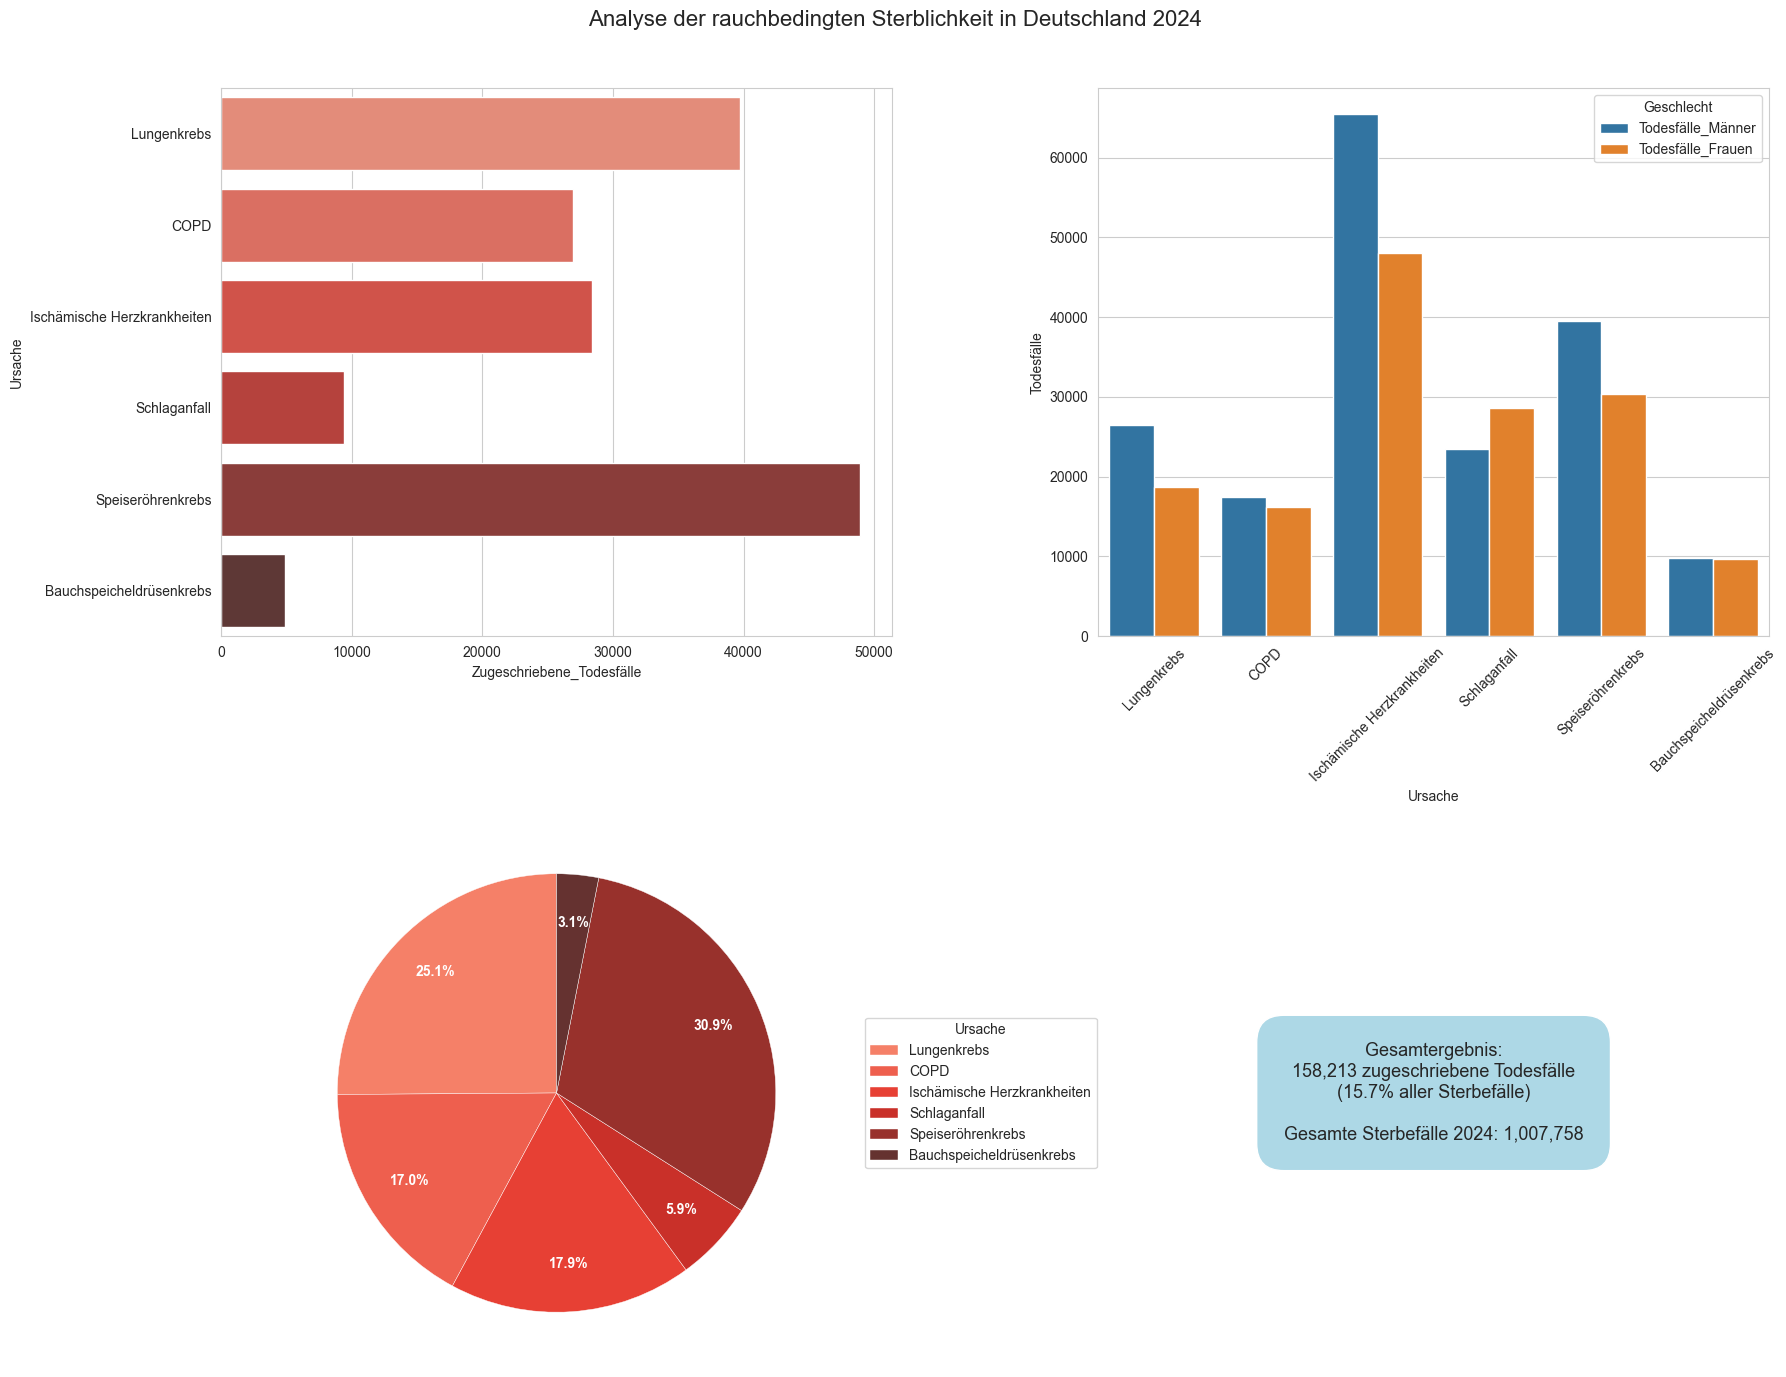

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# =========================================================
# Pfad zur Excel-Datei

script_dir = r'c:\UNI\Meine Programme\INForm_prom\GitHub\Informprojekt_SoSe2026\__Sterblichkeit__'
file_name = 'statistischer-bericht-todesursachen-2120400247005.xlsx'
file_path = os.path.join(script_dir, file_name)

# =========================================================
# Funktionen und Konstanten

plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style("whitegrid")

SAF = {'C34': 0.88, 'J44': 0.80, 'I20-I25': 0.25, 
       'I60-I69': 0.18, 'C15': 0.70, 'C25': 0.25}

causes_names = {
    'C34': 'Lungenkrebs', 'J44': 'COPD',
    'I20-I25': 'Ischämische Herzkrankheiten',
    'I60-I69': 'Schlaganfall',
    'C15': 'Speiseröhrenkrebs',
    'C25': 'Bauchspeicheldrüsenkrebs'
}

# =========================================================
# Daten laden und vorbereiten

df_total = pd.read_excel(file_path, sheet_name='23211-b09', header=3)
df_male = pd.read_excel(file_path, sheet_name='23211-b10', header=3)
df_female = pd.read_excel(file_path, sheet_name='23211-b11', header=3)

def get_deaths_by_icd(df, icd_prefix):
    col0 = df.iloc[:, 0].astype(str).str.strip()
    mask = col0.str.startswith(icd_prefix)
    if mask.any():
        return int(df.loc[mask, df.columns[1]].iloc[0])
    return 0

total_deaths = get_deaths_by_icd(df_total, 'A00-U85')

# =========================================================
# Analyse der rauchbedingten Sterblichkeit

results = []
for code, name in causes_names.items():
    dt = get_deaths_by_icd(df_total, code)
    dm = get_deaths_by_icd(df_male, code)
    df_ = get_deaths_by_icd(df_female, code)
    saf = SAF.get(code, 0.0)
    results.append({
        'Ursache': name,
        'ICD': code,
        'Todesfälle_Gesamt': dt,
        'Todesfälle_Männer': dm,
        'Todesfälle_Frauen': df_,
        'SAF': saf,
        'Zugeschriebene_Todesfälle': round(dt * saf),
        'Anteil_Gesamt_%': round(dt / total_deaths * 100, 2) if total_deaths > 0 else 0,
    })

df_results = pd.DataFrame(results)
print(df_results.round(2).to_string(index=False))

# =========================================================
# Farbpalette

colors = sns.color_palette("Reds_d", len(df_results))

# =========================================================
# Diagramme erstellen

# 1. Bar Chart - Zugeschriebene Todesfälle
fig1, ax1 = plt.subplots(figsize=(10, 6))
sns.barplot(data=df_results, x='Zugeschriebene_Todesfälle', y='Ursache', 
            palette=colors, ax=ax1)
ax1.set_title('Zugeschriebene Sterbefälle durch Rauchen (2024)')
for i, v in enumerate(df_results['Zugeschriebene_Todesfälle']):
    ax1.text(v + 200, i, f'{v:,}', va='center')
plt.tight_layout()
plt.savefig(os.path.join(script_dir, '01_Zugeschriebene_Sterblichkeit.png'), dpi=300)
plt.close(fig1)

# 2. Geschlechtsspezifische Bar Chart
df_gender = df_results[['Ursache','Todesfälle_Männer','Todesfälle_Frauen']].melt(
    id_vars='Ursache', var_name='Geschlecht', value_name='Todesfälle')

fig2, ax2 = plt.subplots(figsize=(12, 7))
sns.barplot(data=df_gender, x='Ursache', y='Todesfälle', hue='Geschlecht', 
            palette=['#1f77b4', '#ff7f0e'], ax=ax2)
ax2.set_title('Rauchbedingte Sterbefälle nach Geschlecht (2024)')
ax2.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(script_dir, '02_Sterblichkeit_nach_Geschlecht.png'), dpi=300)
plt.close(fig2)

# 3. Pie Chart - Struktur der rauchbedingten Sterblichkeit
fig3, ax3 = plt.subplots(figsize=(11, 9))
wedges, texts, autotexts = ax3.pie(
    df_results['Zugeschriebene_Todesfälle'],
    labels=None,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    pctdistance=0.78,
    wedgeprops=dict(linewidth=0.3, edgecolor='white')
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(11)

ax3.legend(wedges, df_results['Ursache'], title="Ursache", 
           loc="center left", bbox_to_anchor=(1.05, 0.5))

ax3.set_title('Struktur der rauchbedingten Sterblichkeit (2024)', fontsize=14)
ax3.set_aspect('equal')
plt.tight_layout()
plt.savefig(os.path.join(script_dir, '03_Struktur_Rauchbedingte_Sterblichkeit.png'), dpi=300, facecolor='white')
plt.close(fig3)

# 4. Gesamtanalyse
fig4, axes = plt.subplots(2, 2, figsize=(18, 14))
total_attributable = df_results['Zugeschriebene_Todesfälle'].sum()
percentage = total_attributable / total_deaths * 100

sns.barplot(data=df_results, x='Zugeschriebene_Todesfälle', y='Ursache', 
            palette=colors, ax=axes[0,0])

sns.barplot(data=df_gender, x='Ursache', y='Todesfälle', hue='Geschlecht', 
            palette=['#1f77b4', '#ff7f0e'], ax=axes[0,1])
axes[0,1].tick_params(axis='x', rotation=45)

w2, t2, at2 = axes[1,0].pie(
    df_results['Zugeschriebene_Todesfälle'],
    labels=None,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    pctdistance=0.78,
    wedgeprops=dict(linewidth=0.3, edgecolor='white')
)
for autotext in at2:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

axes[1,0].legend(w2, df_results['Ursache'], title="Ursache", 
                 loc="center left", bbox_to_anchor=(1.05, 0.5))

text = f'Gesamtergebnis:\n{total_attributable:,} zugeschriebene Todesfälle\n({percentage:.1f}% aller Sterbefälle)\n\nGesamte Sterbefälle 2024: {total_deaths:,}'
axes[1,1].text(0.5, 0.5, text, ha='center', va='center', fontsize=13,
               bbox=dict(boxstyle="round,pad=1.5", facecolor="lightblue"))
axes[1,1].axis('off')

plt.suptitle('Analyse der rauchbedingten Sterblichkeit in Deutschland 2024', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(os.path.join(script_dir, '04_Gesamtanalyse_Rauchbedingte_Sterblichkeit.png'), dpi=300, facecolor='white')
plt.show()